In [1]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
#KGAT_d2364ccd6738943c0ea003e7f39977a6
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [2]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

bike_sharing_demand_path = kagglehub.competition_download('bike-sharing-demand')

print('Data source import complete.')


100%|██████████| 189k/189k [00:00<00:00, 66.3MB/s]

Extracting files...
Data source import complete.


In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [5]:
import os
df = pd.read_csv(os.path.join(bike_sharing_demand_path, 'train.csv'))
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [6]:
df.shape

(10886, 12)

In [7]:
df.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


In [8]:
df = df.drop('registered',axis = 1)
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1


In [28]:
df = df.sort_values("datetime").reset_index(drop=True)
df["datetime"] = pd.to_datetime(df["datetime"])

df["year"] = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month
df["day"] = df["datetime"].dt.day
df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.weekday

df["year_month"] = (
    df["year"] * 12 + df["month"]
)

df["rush_hour"] = (
    df["hour"].isin([7, 8, 9, 16, 17, 18, 19])
).astype(int)

df["is_weekend"] = (
    df["weekday"] >= 5
).astype(int)
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,count,year,month,day,hour,weekday,year_month,rush_hour,is_weekend
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,16,2011,1,1,0,5,24133,0,1
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,40,2011,1,1,1,5,24133,0,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,32,2011,1,1,2,5,24133,0,1
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,13,2011,1,1,3,5,24133,0,1
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,2011,1,1,4,5,24133,0,1


In [29]:
x = df.drop(['datetime','casual','count'],axis = 1)
y = df['count']

In [30]:
x.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,hour,weekday,year_month,rush_hour,is_weekend
0,1,0,0,1,9.84,14.395,81,0.0,2011,1,1,0,5,24133,0,1
1,1,0,0,1,9.02,13.635,80,0.0,2011,1,1,1,5,24133,0,1
2,1,0,0,1,9.02,13.635,80,0.0,2011,1,1,2,5,24133,0,1
3,1,0,0,1,9.84,14.395,75,0.0,2011,1,1,3,5,24133,0,1
4,1,0,0,1,9.84,14.395,75,0.0,2011,1,1,4,5,24133,0,1


In [67]:
 from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
     x,
     y,
     test_size=0.2,
     random_state=42
 )

In [68]:
from sklearn.preprocessing import StandardScaler

split = int(len(df) * 0.8)

x_train_unscaled = x[:split] # Use array slicing for x (numpy array)
x_test_unscaled = x[split:]  # Use array slicing for x (numpy array)

y_train = y.iloc[:split]
y_test = y.iloc[split:]

s = StandardScaler()
x_train = s.fit_transform(x_train_unscaled)
x_test = s.transform(x_test_unscaled)

In [69]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train, y_train)

lr_pred = lr.predict(x_test)

In [70]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train, y_train)

rf_pred = rf.predict(x_test)

In [71]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)

gb.fit(x_train, y_train)

gb_pred = gb.predict(x_test)

In [72]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=3,
    objective="reg:squarederror",
    random_state=42
)

xgb.fit(x_train, y_train)

xgb_pred = xgb.predict(x_test)

In [73]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

def evaluate_model(name, actual, predicted):

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)

    print(name)
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R²  :", r2)
    print("-" * 40)
evaluate_model("Linear Regression", y_test, lr_pred)
evaluate_model("Random Forest", y_test, rf_pred)
evaluate_model("Gradient Boosting", y_test, gb_pred)
evaluate_model("XGBoost", y_test, xgb_pred)

Linear Regression
MAE : 115.56260145521458
RMSE: 154.53603039194246
R²  : 0.49562428164632777
----------------------------------------
Random Forest
MAE : 41.173029285570976
RMSE: 65.3271463768581
R²  : 0.9098673704107553
----------------------------------------
Gradient Boosting
MAE : 55.51551104251185
RMSE: 80.24000223451715
R²  : 0.8640195323593816
----------------------------------------
XGBoost
MAE : 35.76667404174805
RMSE: 55.37013901844455
R²  : 0.9352490901947021
----------------------------------------


In [75]:
train_r2 = xgb.score(x_train, y_train)
test_r2 = xgb.score(x_test, y_test)

print("Train R²:", train_r2)
print("Test R² :", test_r2)
print("Gap     :", train_r2 - test_r2)

Train R²: 0.9783353209495544
Test R² : 0.9352490901947021
Gap     : 0.043086230754852295


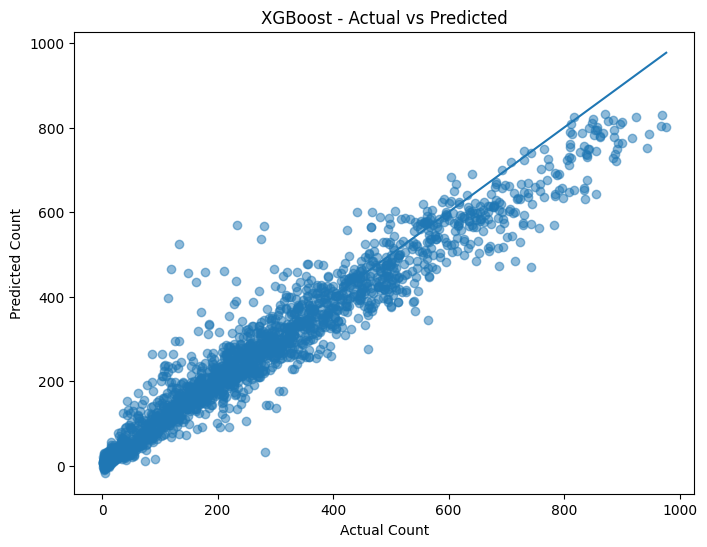

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, xgb_pred, alpha=0.5)

plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.title("XGBoost - Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()